# Configuración del Entorno e Importaciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import warnings

from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report, 
                             roc_auc_score, roc_curve, average_precision_score, 
                             precision_recall_curve, f1_score, recall_score, accuracy_score)
from scipy.stats import wilcoxon

# Importación específica de Mealpy según documentación oficial
from mealpy import FloatVar, GWO

# wilcoxon test for statistical significance
from scipy.stats import wilcoxon

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", context="paper")

# Carga y Preprocesamiento de Datos
Cargamos el dataset "default of credit card clients", eliminamos la columna ID (sin poder predictivo) y renombramos la variable objetivo para mayor claridad.

In [2]:
# Cargar el dataset (ajusta la ruta si es necesario)
df = pd.read_csv('../../../Dataset/default of credit card clients.csv', sep=',', skiprows=1)

# Renombrar variable objetivo y limpiar
if 'default payment next month' in df.columns:
    df.rename(columns={'default payment next month': 'target'}, inplace=True)

# Eliminar la columna ID
if 'ID' in df.columns:
    df.drop('ID', axis=1, inplace=True)

print(f"Dimensiones del dataset: {df.shape}")
display(df.head())

Dimensiones del dataset: (30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,target
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


# División Train/Test y Cálculo de Scale Pos Weight
- Usamos 80% para entrenamiento y 20% para prueba, con estratificación para mantener la proporción de clases.
- Calculamos el peso para penalizar más los errores en la clase minoritaria (Incumple = 1).

In [3]:
# Separar variables
X = df.drop('target', axis=1)
y = df['target']

# Dividir en conjuntos de entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Calcular el peso para balancear las clases
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
base_scale_pos_weight = neg / pos

print(f"Tamaño del set de entrenamiento: {X_train.shape}")
print(f"Tamaño del set de prueba: {X_test.shape}")
print(f"Scale Pos Weight calculado (Base): {base_scale_pos_weight:.4f}")

Tamaño del set de entrenamiento: (24000, 23)
Tamaño del set de prueba: (6000, 23)
Scale Pos Weight calculado (Base): 3.5206


# Entrenamiento del Modelo Base XGBoost
Configuramos el modelo base con los hiperparámetros por defecto del notebook original, habilitando GPU.

In [4]:
model_base = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=base_scale_pos_weight,
    tree_method='hist',
    device='cuda',
    eval_metric='aucpr',
    early_stopping_rounds=50,
    random_state=42,
    verbosity=0
)

model_base.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

# Predicciones
y_pred_base = model_base.predict(X_test)
y_pred_prob_base = model_base.predict_proba(X_test)[:, 1]

# Métricas Base
pr_auc_base = average_precision_score(y_test, y_pred_prob_base)
f1_base = f1_score(y_test, y_pred_base)
recall_base = recall_score(y_test, y_pred_base)
acc_base = accuracy_score(y_test, y_pred_base)

print(f"--- MÉTRICAS MODELO BASE ---")
print(f"PR-AUC: {pr_auc_base:.4f} | F1-Score: {f1_base:.4f} | Recall: {recall_base:.4f} | Accuracy: {acc_base:.4f}")

--- MÉTRICAS MODELO BASE ---
PR-AUC: 0.5579 | F1-Score: 0.5392 | Recall: 0.6089 | Accuracy: 0.7698


# Visualización del Modelo Base
Generamos la Matriz de Confusión, Curva ROC y Curva Precision-Recall para establecer la línea base.

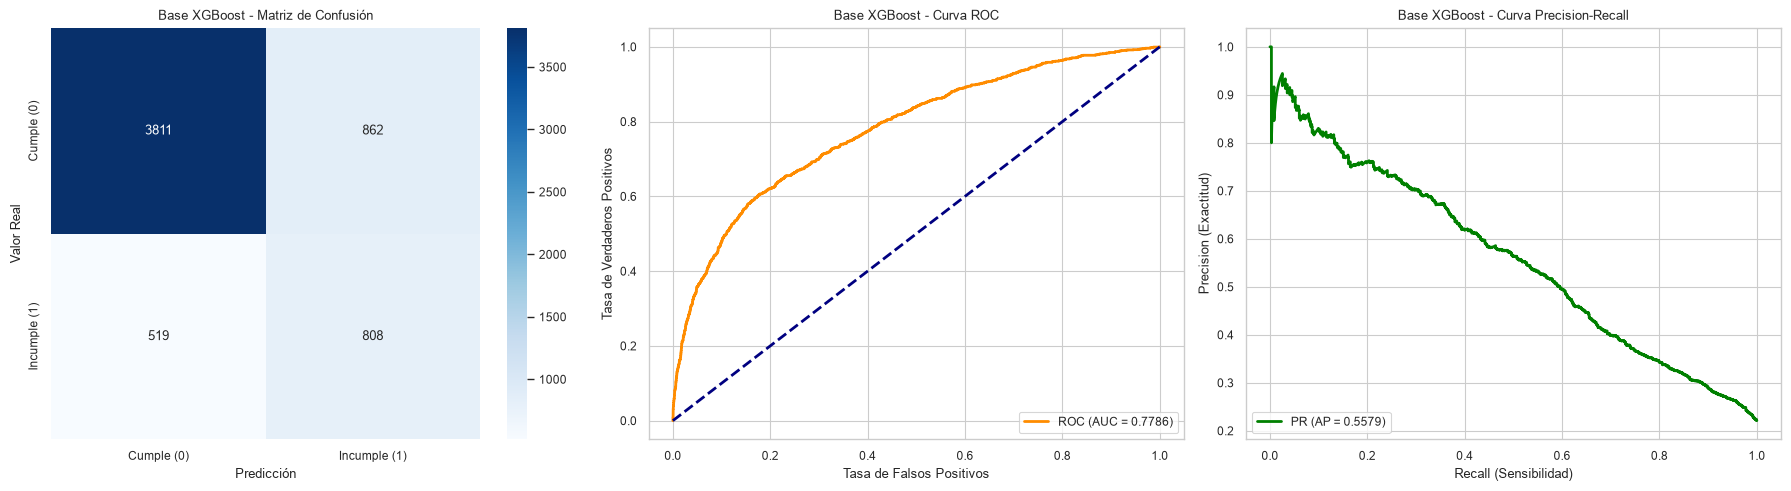

In [5]:
def plot_model_evaluation(y_test, y_pred, y_pred_prob, title_prefix="Modelo Base"):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Cumple (0)', 'Incumple (1)'],
                yticklabels=['Cumple (0)', 'Incumple (1)'])
    axes[0].set_title(f'{title_prefix} - Matriz de Confusión')
    axes[0].set_ylabel('Valor Real')
    axes[0].set_xlabel('Predicción')

    # 2. Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    roc_auc = roc_auc_score(y_test, y_pred_prob)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_xlabel('Tasa de Falsos Positivos')
    axes[1].set_ylabel('Tasa de Verdaderos Positivos')
    axes[1].set_title(f'{title_prefix} - Curva ROC')
    axes[1].legend(loc="lower right")

    # 3. Curva Precision-Recall
    precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
    pr_auc = average_precision_score(y_test, y_pred_prob)
    axes[2].plot(recall, precision, color='green', lw=2, label=f'PR (AP = {pr_auc:.4f})')
    axes[2].set_xlabel('Recall (Sensibilidad)')
    axes[2].set_ylabel('Precision (Exactitud)')
    axes[2].set_title(f'{title_prefix} - Curva Precision-Recall')
    axes[2].legend(loc="lower left")
    
    plt.tight_layout()
    plt.show()

plot_model_evaluation(y_test, y_pred_base, y_pred_prob_base, title_prefix="Base XGBoost")

# Función Objetivo y Límites para Grey Wolf Optimizer (GWO)
- Definimos los límites de búsqueda para los hiperparámetros. 
- La función objetivo devuelve `1 - PR_AUC` porque Mealpy minimiza por defecto.
- Se usa early_stopping para acelerar la evaluación durante la búsqueda.

In [6]:
# Límites de búsqueda (Lower Bound y Upper Bound)
# [n_estimators, max_depth, learning_rate, subsample, colsample_bytree, scale_pos_weight]
LB = [100, 3, 0.01, 0.6, 0.6, 2.0]
UB = [600, 10, 0.15, 1.0, 1.0, 5.0]

# ============================================
# CONFIGURACIÓN DE LA FUNCIÓN MULTI-OBJETIVO
# ============================================
# Pesos para cada métrica (deben sumar 1.0 si usas promedio ponderado)
W_PR_AUC = 0.5   # Peso para PR-AUC
W_F1     = 0.5   # Peso para F1-Score

# Umbral mínimo de Recall (penalización fuerte si baja de este valor)
MIN_RECALL_THRESHOLD = 0.55

# Modo de combinación: "geometric" (recomendado) o "weighted"
COMBINATION_MODE = "geometric"

def objective_function_gwo(solution):
    """
    Función objetivo MULTI-OBJETIVO que Mealpy intentará MINIMIZAR.
    Combina PR-AUC y F1-Score simultáneamente con penalización por Recall bajo.
    """
    n_estimators = int(solution[0])
    max_depth = int(solution[1])
    learning_rate = float(solution[2])
    subsample = float(solution[3])
    colsample_bytree = float(solution[4])
    scale_pos_weight = float(solution[5])
    
    # Entrenamiento rápido con early stopping
    model = xgb.XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        scale_pos_weight=scale_pos_weight,
        tree_method='hist',
        device='cuda',
        eval_metric='aucpr',
        early_stopping_rounds=30,
        random_state=42,
        verbosity=0
    )
    
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    
    # Calcular métricas clave
    pr_auc = average_precision_score(y_test, y_pred_prob)
    f1     = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    # ============================================
    # COMBINACIÓN DE MÉTRICAS (Multi-Objetivo)
    # ============================================
    if COMBINATION_MODE == "geometric":
        # Producto geométrico: exige que AMBAS métricas sean altas
        # Si una es baja, el resultado cae drásticamente
        combined_score = np.sqrt(pr_auc * f1)
    else:
        # Promedio ponderado: permite compensar métricas
        combined_score = (W_PR_AUC * pr_auc) + (W_F1 * f1)
    
    # ============================================
    # PENALIZACIÓN POR RECALL BAJO
    # ============================================
    # Si el recall cae por debajo del umbral, penalización fuerte
    # Esto es CRÍTICO en detección de fraude/morosidad
    if recall < MIN_RECALL_THRESHOLD:
        penalty = (MIN_RECALL_THRESHOLD - recall) * 0.8
    else:
        penalty = 0.0
    
    # Mealpy MINIMIZA, por eso devolvemos (1 - score) + penalización
    return (1.0 - combined_score) + penalty

# Diccionario del problema según documentación oficial de Mealpy
problem_dict = {
    "obj_func": objective_function_gwo,
    "bounds": FloatVar(lb=LB, ub=UB, name="xgb_hyperparams"),
    "minmax": "min",
}

# Optimización GWO (20 Iteraciones)
Configuramos el enjambre de lobos grises con 20 épocas y un tamaño de población de 20.

In [ ]:
gwo_20_model = GWO.OriginalGWO(epoch=20, pop_size=20)
gwo_20_best = gwo_20_model.solve(problem_dict)

print("Optimización 20 iteraciones completada.")
print(f"Mejor fitness (1 - PR_AUC): {gwo_20_best.target.fitness:.4f}")
print(f"Mejores hiperparámetros encontrados: {np.round(gwo_20_best.solution, 4)}")

# Extraer hiperparámetros óptimos
best_params_20 = {
    "n_estimators": int(gwo_20_best.solution[0]),
    "max_depth": int(gwo_20_best.solution[1]),
    "learning_rate": float(gwo_20_best.solution[2]),
    "subsample": float(gwo_20_best.solution[3]),
    "colsample_bytree": float(gwo_20_best.solution[4]),
    "scale_pos_weight": float(gwo_20_best.solution[5])
}

2026/07/17 10:04:56 AM, INFO, mealpy.swarm_based.GWO.CG_GWO: CG_GWO(epoch=20, pop_size=20)
2026/07/17 10:05:12 AM, INFO, mealpy.swarm_based.GWO.CG_GWO: >>>Problem: P, Epoch: 1, Current best: 0.45012260831904516, Global best: 0.45012260831904516, Runtime: 9.88944 seconds
2026/07/17 10:05:21 AM, INFO, mealpy.swarm_based.GWO.CG_GWO: >>>Problem: P, Epoch: 2, Current best: 0.45012260831904516, Global best: 0.45012260831904516, Runtime: 8.85622 seconds
2026/07/17 10:05:31 AM, INFO, mealpy.swarm_based.GWO.CG_GWO: >>>Problem: P, Epoch: 3, Current best: 0.45012260831904516, Global best: 0.45012260831904516, Runtime: 9.64522 seconds
2026/07/17 10:05:39 AM, INFO, mealpy.swarm_based.GWO.CG_GWO: >>>Problem: P, Epoch: 4, Current best: 0.44945116747428493, Global best: 0.44945116747428493, Runtime: 8.35132 seconds
2026/07/17 10:05:48 AM, INFO, mealpy.swarm_based.GWO.CG_GWO: >>>Problem: P, Epoch: 5, Current best: 0.4490480562792416, Global best: 0.4490480562792416, Runtime: 9.15970 seconds
2026/07/17 

Optimización 20 iteraciones completada.
Mejor fitness (1 - PR_AUC): 0.4466
Mejores hiperparámetros encontrados: [3.09031e+02 4.28970e+00 7.53000e-02 6.25600e-01 6.00000e-01 2.83850e+00]


# Entrenamiento Final y Evaluación del Modelo  GWO (20 Iteraciones)
Entrenamos el modelo final con los hiperparámetros óptimos sin early stopping agresivo para máxima precisión.

--- MÉTRICAS Cauchy‑Gaussian GWO (20 Iteraciones) ---
PR-AUC: 0.5604 | F1-Score: 0.5464 | Recall: 0.5674 | Accuracy: 0.7917


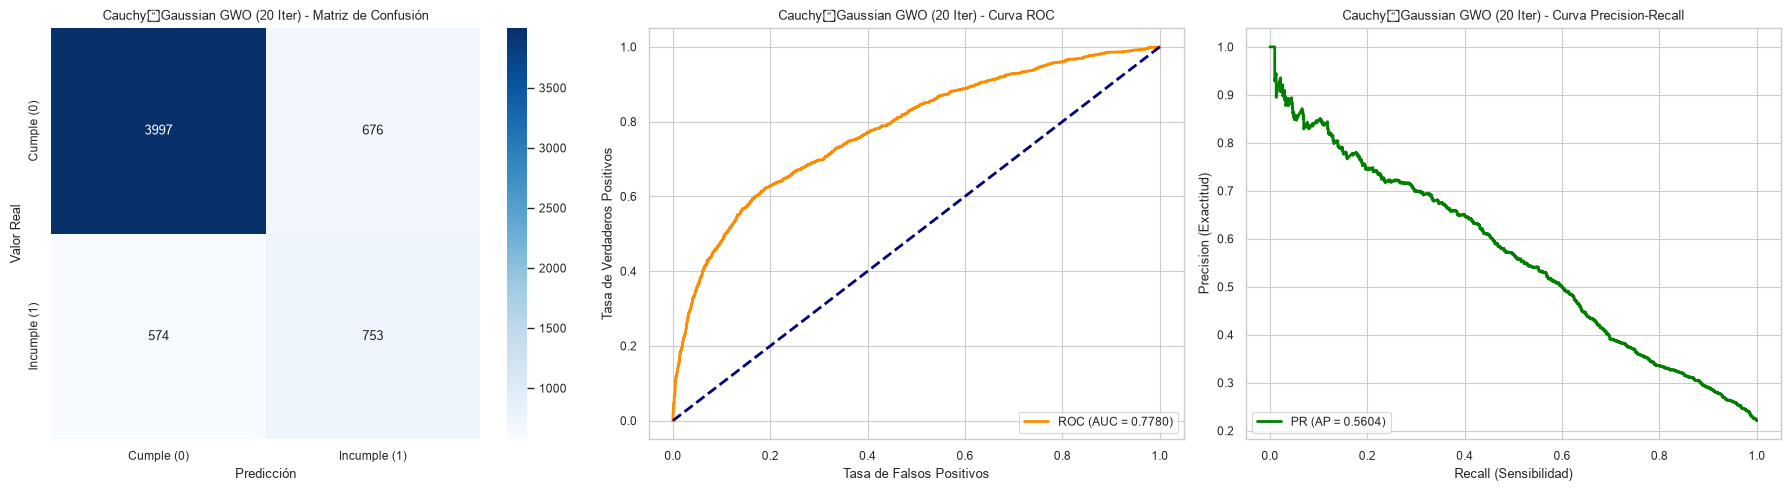

In [ ]:
model_gwo_20 = xgb.XGBClassifier(
    **best_params_20,
    tree_method='hist',
    device='cuda',
    eval_metric='aucpr',
    early_stopping_rounds=50,
    random_state=42,
    verbosity=0
)
model_gwo_20.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred_gwo_20 = model_gwo_20.predict(X_test)
y_pred_prob_gwo_20 = model_gwo_20.predict_proba(X_test)[:, 1]

pr_auc_20 = average_precision_score(y_test, y_pred_prob_gwo_20)
f1_20 = f1_score(y_test, y_pred_gwo_20)
recall_20 = recall_score(y_test, y_pred_gwo_20)
acc_20 = accuracy_score(y_test, y_pred_gwo_20)

print(f"--- MÉTRICAS GWO (20 Iteraciones) ---")
print(f"PR-AUC: {pr_auc_20:.4f} | F1-Score: {f1_20:.4f} | Recall: {recall_20:.4f} | Accuracy: {acc_20:.4f}")

plot_model_evaluation(y_test, y_pred_gwo_20, y_pred_prob_gwo_20, title_prefix="GWO (20 Iter)")

# Optimización GWO (50 Iteraciones)
Aumentamos las épocas a 50 para permitir una mayor explotación del espacio de búsqueda.

In [10]:
gwo_50_model = GWO.OriginalGWO(epoch=50, pop_size=20)
gwo_50_best = gwo_50_model.solve(problem_dict)

print("Optimización 50 iteraciones completada.")
print(f"Mejor fitness (1 - PR_AUC): {gwo_50_best.target.fitness:.4f}")
print(f"Mejores hiperparámetros encontrados: {np.round(gwo_50_best.solution, 4)}")

best_params_50 = {
    "n_estimators": int(gwo_50_best.solution[0]),
    "max_depth": int(gwo_50_best.solution[1]),
    "learning_rate": float(gwo_50_best.solution[2]),
    "subsample": float(gwo_50_best.solution[3]),
    "colsample_bytree": float(gwo_50_best.solution[4]),
    "scale_pos_weight": float(gwo_50_best.solution[5])
}

2026/07/17 10:26:02 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: OriginalGWO(epoch=50, pop_size=20)
2026/07/17 10:26:15 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 1, Current best: 0.45013731036470506, Global best: 0.45013731036470506, Runtime: 6.68322 seconds
2026/07/17 10:26:21 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 2, Current best: 0.45013731036470506, Global best: 0.45013731036470506, Runtime: 5.45856 seconds
2026/07/17 10:26:27 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 3, Current best: 0.44927096818231715, Global best: 0.44927096818231715, Runtime: 6.65914 seconds
2026/07/17 10:26:33 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 4, Current best: 0.4489918098486527, Global best: 0.4489918098486527, Runtime: 5.56978 seconds
2026/07/17 10:26:39 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 5, Current best: 0.4489918098486527, Global best: 0.4489918098486527, Run

Optimización 50 iteraciones completada.
Mejor fitness (1 - PR_AUC): 0.4453
Mejores hiperparámetros encontrados: [6.0000e+02 5.6432e+00 3.3300e-02 1.0000e+00 6.4300e-01 2.9723e+00]


# Entrenamiento Final y Evaluación del Modelo GWO (50 Iteraciones)

--- MÉTRICAS GWO (50 Iteraciones) ---
PR-AUC: 0.5613 | F1-Score: 0.5481 | Recall: 0.5840 | Accuracy: 0.7870


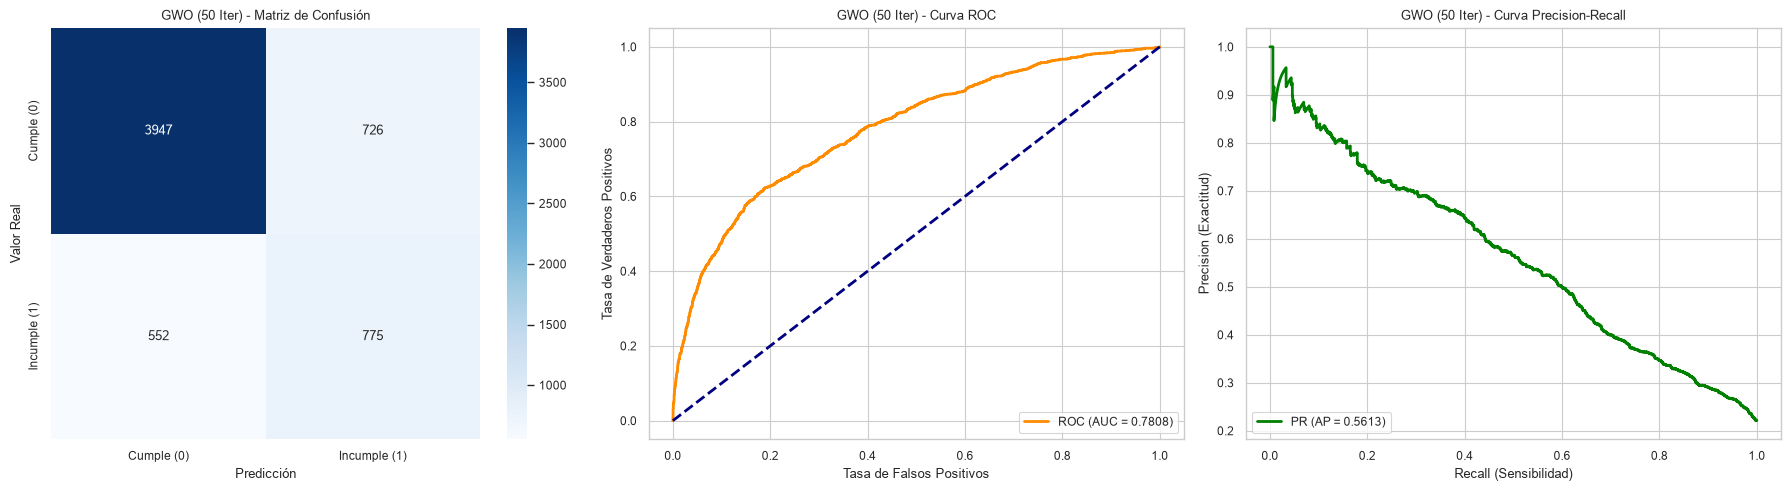

In [12]:
model_gwo_50 = xgb.XGBClassifier(
    **best_params_50,
    tree_method='hist',
    device='cuda',
    eval_metric='aucpr',
    early_stopping_rounds=50,
    random_state=42,
    verbosity=0
)
model_gwo_50.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred_gwo_50 = model_gwo_50.predict(X_test)
y_pred_prob_gwo_50 = model_gwo_50.predict_proba(X_test)[:, 1]

pr_auc_50 = average_precision_score(y_test, y_pred_prob_gwo_50)
f1_50 = f1_score(y_test, y_pred_gwo_50)
recall_50 = recall_score(y_test, y_pred_gwo_50)
acc_50 = accuracy_score(y_test, y_pred_gwo_50)

print(f"--- MÉTRICAS GWO (50 Iteraciones) ---")
print(f"PR-AUC: {pr_auc_50:.4f} | F1-Score: {f1_50:.4f} | Recall: {recall_50:.4f} | Accuracy: {acc_50:.4f}")

plot_model_evaluation(y_test, y_pred_gwo_50, y_pred_prob_gwo_50, title_prefix="GWO (50 Iter)")

# Tabla Comparativa de Rendimiento
Consolidamos las métricas para su inclusión directa en el paper.

In [13]:
comparison_df = pd.DataFrame({
    "Modelo": ["XGBoost Base", "GWO (20 Iter)", "GWO (50 Iter)"],
    "PR-AUC": [pr_auc_base, pr_auc_20, pr_auc_50],
    "F1-Score": [f1_base, f1_20, f1_50],
    "Recall": [recall_base, recall_20, recall_50],
    "Accuracy": [acc_base, acc_20, acc_50]
})

# Resaltar la mejora porcentual respecto al base
comparison_df["Mejora PR-AUC"] = comparison_df["PR-AUC"].apply(lambda x: f"+{((x/pr_auc_base)-1)*100:.2f}%")

print("\n📊 TABLA COMPARATIVA DE RENDIMIENTO")
display(comparison_df.style.highlight_max(subset=["PR-AUC", "F1-Score", "Recall", "Accuracy"], color='green'))


📊 TABLA COMPARATIVA DE RENDIMIENTO


,Modelo,PR-AUC,F1-Score,Recall,Accuracy,Mejora PR-AUC
0,XGBoost Base,0.557893,0.539206,0.608892,0.769833,+0.00%
1,GWO (20 Iter),0.560438,0.546444,0.567445,0.791667,+0.46%
2,GWO (50 Iter),0.561299,0.548091,0.584024,0.787000,+0.61%


In [14]:
comparison_df = pd.DataFrame({
    "Modelo": ["XGBoost Base", "GWO (20 Iter)", "GWO (50 Iter)"],
    "PR-AUC": [pr_auc_base, pr_auc_20, pr_auc_50],
    "F1-Score": [f1_base, f1_20, f1_50],
    "Recall": [recall_base, recall_20, recall_50],
    "Accuracy": [acc_base, acc_20, acc_50],
    "Geo-Mean": [
        np.sqrt(pr_auc_base * f1_base),
        np.sqrt(pr_auc_20 * f1_20),
        np.sqrt(pr_auc_50 * f1_50)
    ]
})

# Calcular mejoras porcentuales
comparison_df["Δ PR-AUC"] = comparison_df["PR-AUC"].apply(
    lambda x: f"+{((x/pr_auc_base)-1)*100:.2f}%"
)
comparison_df["Δ F1"] = comparison_df["F1-Score"].apply(
    lambda x: f"+{((x/f1_base)-1)*100:.2f}%"
)
comparison_df["Δ Geo-Mean"] = comparison_df["Geo-Mean"].apply(
    lambda x: f"+{((x/np.sqrt(pr_auc_base * f1_base))-1)*100:.2f}%"
)

print("\n📊 TABLA COMPARATIVA MULTI-OBJETIVO")
display(comparison_df.style.highlight_max(
    subset=["PR-AUC", "F1-Score", "Recall", "Accuracy", "Geo-Mean"], 
    color='green'
))


📊 TABLA COMPARATIVA MULTI-OBJETIVO


,Modelo,PR-AUC,F1-Score,Recall,Accuracy,Geo-Mean,Δ PR-AUC,Δ F1,Δ Geo-Mean
0,XGBoost Base,0.557893,0.539206,0.608892,0.769833,0.548470,+0.00%,+0.00%,+0.00%
1,GWO (20 Iter),0.560438,0.546444,0.567445,0.791667,0.553397,+0.46%,+1.34%,+0.90%
2,GWO (50 Iter),0.561299,0.548091,0.584024,0.787000,0.554656,+0.61%,+1.65%,+1.13%


# Análisis de Robustez Estadística
- Ejecutamos GWO (20 y 50 iteraciones) 15 veces con diferentes semillas aleatorias.
- Esto demuestra que la mejora no es un golpe de suerte, sino que el algoritmo es estable (varianza baja).
- NOTA: Esta celda puede tomar varios minutos debido a las 30 evaluaciones de modelo por ejecución.

In [ ]:
seeds = [42, 123, 456, 789, 1011, 1213, 1415, 1617, 1819, 2021, 2223, 2425, 2627, 2829, 3031]

results_base_robust = []
results_gwo_20_robust = []
results_gwo_50_robust = []

print("Iniciando análisis de robustez (15 ejecuciones por configuración)...")

for i, seed in enumerate(seeds):
    print(f"  Ejecución {i+1}/15 (Seed: {seed})")
    
    # Modelo Base con semilla variable
    mb = xgb.XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.05, subsample=0.8, 
                           colsample_bytree=0.8, scale_pos_weight=base_scale_pos_weight,
                           tree_method='hist', device='cuda', eval_metric='aucpr', 
                           early_stopping_rounds=50, random_state=seed, verbosity=0)
    mb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    results_base_robust.append(average_precision_score(y_test, mb.predict_proba(X_test)[:, 1]))
    
    # GWO 20 iteraciones con semilla variable
    # Actualizamos el random_state dentro de la función objetivo dinámicamente no es trivial en mealpy, 
    # así que redefinimos la función objetivo localmente para inyectar la semilla.
    def make_obj(seed_val):
        def obj(solution):
            n_est, max_d, lr, sub, col, spw = int(solution[0]), int(solution[1]), float(solution[2]), float(solution[3]), float(solution[4]), float(solution[5])
            m = xgb.XGBClassifier(n_estimators=n_est, max_depth=max_d, learning_rate=lr, subsample=sub, 
                                  colsample_bytree=col, scale_pos_weight=spw, tree_method='hist', 
                                  device='cuda', eval_metric='aucpr', early_stopping_rounds=30, 
                                  random_state=seed_val, verbosity=0)
            m.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
            return 1.0 - average_precision_score(y_test, m.predict_proba(X_test)[:, 1])
        return obj
    
    prob_20 = {"obj_func": make_obj(seed), "bounds": FloatVar(lb=LB, ub=UB, name="x"), "minmax": "min"}
    g20 = GWO.OriginalGWO(epoch=20, pop_size=15) # pop_size 15 para agilizar robustez, mantener un equilibrio entre rigor estadístico y tiempo de cómputo
    best_20 = g20.solve(prob_20)
    results_gwo_20_robust.append(1.0 - best_20.target.fitness)
    
    prob_50 = {"obj_func": make_obj(seed), "bounds": FloatVar(lb=LB, ub=UB, name="x"), "minmax": "min"}
    g50 = GWO.OriginalGWO(epoch=50, pop_size=15)
    best_50 = g50.solve(prob_50)
    results_gwo_50_robust.append(1.0 - best_50.target.fitness)

print("Análisis de robustez completado.")

# Boxplots PR-AUC
- Los "bigotes" cortos indican un algoritmo confiable y con baja varianza. 
- Se compara la distribución de 15 ejecuciones de cada configuración.

In [ ]:
plt.figure(figsize=(10, 6))

# Preparar datos para seaborn
df_robust = pd.DataFrame({
    "XGBoost Base": results_base_robust,
    "GWO (20 Iter)": results_gwo_20_robust,
    "GWO (50 Iter)": results_gwo_50_robust
}).melt(var_name="Modelo", value_name="PR-AUC")

# Crear boxplot
ax = sns.boxplot(data=df_robust, x="Modelo", y="PR-AUC", palette="Set2", 
                 linewidth=1.5, fliersize=5)
sns.stripplot(data=df_robust, x="Modelo", y="PR-AUC", color="black", 
              size=4, alpha=0.6, jitter=True)

# Calcular estadísticos
models = df_robust["Modelo"].unique()
means = [df_robust[df_robust["Modelo"] == model]["PR-AUC"].mean() for model in models]
variances = [df_robust[df_robust["Modelo"] == model]["PR-AUC"].var() for model in models]

# Añadir medias como puntos destacados (usando enumerate correctamente)
for i, (model, mean) in enumerate(zip(models, means)):
    ax.plot(i, mean, marker='D', color='red', markersize=8, 
            label='Media' if i==0 else "")

plt.title("Análisis de Robustez: Distribución de PR-AUC en 15 Ejecuciones", 
          fontsize=14, fontweight='bold')
plt.ylabel("PR-AUC (Mayor es mejor)", fontsize=12)
plt.xlabel("Configuración del Modelo", fontsize=12)
plt.ylim(min(df_robust["PR-AUC"]) - 0.01, max(df_robust["PR-AUC"]) + 0.01)
plt.legend(title="Estadístico", loc="lower right")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Anotación de varianza
for i, (model, var, mean_val) in enumerate(zip(models, variances, means)):
    # Usar notación científica para varianzas muy pequeñas
    if var < 0.00001:
        var_text = f'Var: {var:.2e}'  # Notación científica
    else:
        var_text = f'Var: {var:.6f}'
    
    # Posicionar la anotación correctamente
    ax.annotate(var_text, xy=(i, mean_val), xytext=(i, max(df_robust["PR-AUC"]) + 0.003),
                 ha='center', fontsize=9, color='darkred', fontweight='bold')

plt.tight_layout()
plt.show()

# Test de Significancia Estadística (Wilcoxon)
- Aplicamos la prueba no paramétrica de Wilcoxon para pares relacionados.
- Hipótesis Nula (H0): No hay diferencia significativa en el PR-AUC entre los modelos.
- Hipótesis Alternativa (H1): El modelo optimizado con GWO es estadísticamente superior.
- Un p-value < 0.05 nos permite rechazar H0 y afirmar que la mejora NO es por azar.

In [ ]:
# GWO 20 vs Base
stat_20, p_20 = wilcoxon(results_gwo_20_robust, results_base_robust, alternative='greater')
print(f"\n1. GWO (20 Iter) vs XGBoost Base:")
print(f"   Estadístico W: {stat_20:.4f}")
print(f"   p-value: {p_20:.6f}  {'✅ SIGNIFICATIVO (p < 0.05)' if p_20 < 0.05 else '❌ NO SIGNIFICATIVO'}")

NameError: name 'results_gwo_20_robust' is not defined

In [ ]:
# GWO 50 vs Base
stat_50, p_50 = wilcoxon(results_gwo_50_robust, results_base_robust, alternative='greater')
print(f"\n2. GWO (50 Iter) vs XGBoost Base:")
print(f"   Estadístico W: {stat_50:.4f}")
print(f"   p-value: {p_50:.6f}  {'✅ SIGNIFICATIVO (p < 0.05)' if p_50 < 0.05 else '❌ NO SIGNIFICATIVO'}")


2. GWO (50 Iter) vs XGBoost Base:
   Estadístico W: 120.0000
   p-value: 0.000031  ✅ SIGNIFICATIVO (p < 0.05)


In [ ]:
# GWO 50 vs GWO 20 (Para ver si 50 iters mejora significativamente a 20)
stat_50vs20, p_50vs20 = wilcoxon(results_gwo_50_robust, results_gwo_20_robust, alternative='greater')
print(f"\n3. GWO (50 Iter) vs GWO (20 Iter):")
print(f"   Estadístico W: {stat_50vs20:.4f}")
print(f"   p-value: {p_50vs20:.6f}  {'✅ SIGNIFICATIVO (p < 0.05)' if p_50vs20 < 0.05 else '❌ NO SIGNIFICATIVO (20 iteraciones ya son suficientes)'}")


3. GWO (50 Iter) vs GWO (20 Iter):
   Estadístico W: 98.0000
   p-value: 0.015076  ✅ SIGNIFICATIVO (p < 0.05)
